<p style="text-align: right;">Quintin Lopez-Scarim</p>

# Problem 1

$$J_{a}(x) = \frac{1}{2} \int_{0}^{t_f}\, [x^{2}(t) + u^{2}(t)] dt + \int_{0}^{t_f}\, [\lambda (f(u,x)-x'(t))] dt $$
where $$f = -x + u$$

$$\lambda (t) = \lambda_0(t)$$

$$ L =  \frac{1}{2}(x^{2}(t) + u^{2}(t))$$

Then:

$$J_{a}(x) = \int_{0}^{t_f}\, [\lambda (f(u,x)-x'(t))] dt $$

where

$$H =  L + \lambda f(u,x)$$

Then: 

$$J_{a}(x) = \int_{0}^{t_f}\, [H - \lambda x'(t)] dt $$

First order optimality condition: 
$$\delta J_{a}(x) = \delta \int_{0}^{t_f}\, [H - \lambda x'(t)] dt = 0 $$

$$\delta J_{a}(x) = \int_{0}^{t_f}\, [\delta H - \delta \lambda x'(t) - \lambda \delta x'(t)] dt = 0 $$

$$\delta J_{a}(x) = \int_{0}^{t_f}\, [\frac{\partial H}{\partial u}\delta u + \frac{\partial H}{\partial {x}}\delta {x} + \frac{\partial H}{\partial \lambda}\delta \lambda  - \delta \lambda x'(t) - \lambda \delta x'(t)] dt = 0 $$

$$\delta H = \frac{\partial H}{\partial u}\delta u + \left(\frac{\partial H}{\partial \underline{x}} + \dot{\underline{\lambda}}\right)\delta \underline{x} + \left(\frac{\partial H}{\partial \underline{\lambda}} - \dot{\underline{x}}\right)\delta \underline{\lambda} = 0$$

Since $\delta u$, $\delta \underline{x}$, $\delta \underline{\lambda}$ are independent, each term must vanish separately:

$$\frac{\partial H}{\partial u} = 0$$

$$\frac{\partial H}{\partial \underline{x}} + \dot{\underline{\lambda}} = 0 \implies \dot{\underline{\lambda}} = -\frac{\partial H}{\partial \underline{x}}$$

$$\frac{\partial H}{\partial \underline{\lambda}} - \dot{\underline{x}} = 0 \implies \dot{\underline{x}} = \frac{\partial H}{\partial \underline{\lambda}}$$

Given:
$$H = \frac{1}{2}(x^2 + u^2) + \lambda(-x + u)$$

Stationarity condition:
$$\frac{\partial H}{\partial u} = u + \lambda = 0 \implies u = -\lambda$$

Costate equation:
$$\dot{\lambda} = -\frac{\partial H}{\partial x} = -\frac{\partial}{\partial x}\left[\frac{1}{2}x^2 + \lambda(-x+u)\right] = -(x - \lambda) = -x + \lambda$$

$$\implies \dot{\lambda} = -x + \lambda$$

State equation:
$$\dot{x} = \frac{\partial H}{\partial \lambda} = -x + u$$

Substituting $u = -\lambda$:
$$\dot{x} = -x - \lambda$$

**Writing as a matrix system:**
$$\begin{pmatrix} \dot{x} \\ \dot{\lambda} \end{pmatrix} = \begin{pmatrix} -1 & -1 \\ -1 & 1 \end{pmatrix} \begin{pmatrix} x \\ \lambda \end{pmatrix}$$

At this point we also apply our given Boundary Conditions:

$$ x(0) = x_0 = 1$$
$$ x(t_f) = x_f = 1$$
$$ t_f = fixed $$


Thus, we must guess $\lambda_{0}$ and then perform integration from $t_0$ to $t_f$ for simple shooting. The analytical solution is included below the simple shooting implementation

<div style="page-break-after: always;"></div>


# Simple shooting implementation

In [1]:
#General python includes that we will be using
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import warnings
#I want to not display warnings for stuff that doesn't matter
warnings.filterwarnings('ignore', message='Creating an ndarray from ragged nested sequences')

In [2]:
A = np.array([[-1, -1],
              [-1,  1]])

def system(t, y):
    return A @ np.array(y)



def integrator(guess, end_time):
    #solve_ivp input:
    #0: func handle with time as first parameter
    #1: time start : time end
    #2: initial value_1 : initial value_2
    # flag: dense_output if we want all t's not just endpoint
    sol = solve_ivp(system, np.array([0, end_time]), np.array([1, guess]), 
                    method='DOP853',
                    rtol=1e-8,
                    atol=1e-8,
                    dense_output=True)
    t = np.linspace(0, end_time, int(10000*end_time ))
    y = sol.sol(t)

    x = y[0]
    lam = y[1]
    return x, lam, t

In [3]:
def error(guess, time):
    x, lam, t = integrator(guess, time)
    return x[-1] - 1

import matplotlib.pyplot as plt

def solve_loop(time_array):
    guess = 0
    for time in time_array:
        solution, info, ier, msg = fsolve(error, 
                                          guess,
                                          args=(time,)
                                          , xtol=1e-8,
                                          full_output=True)
        lambda_0 = solution[0]
        x, lam, t = integrator(lambda_0, time)
        
        # u(t) = -lambda(t)
        u = -lam
        
        print(f"tf={time}: lambda(0) = {lambda_0:.10f}, x(tf) = {x[-1]:.10f}")
        print(f"u(0) = {u[0]:.10f}, u(tf) = {u[-1]:.10f}")
        print(f"Converged: {ier==1}, message: {msg}\n")
        
        guess = lambda_0
        #guess = 0


In [4]:
time_array = [10, 20, 30, 40, 50]
solve_loop(time_array)

tf=10: lambda(0) = 0.4142115221, x(tf) = 1.0000000002
u(0) = -0.4142115221, u(tf) = 2.4142115225
Converged: True, message: The solution converged.

tf=20: lambda(0) = 0.4142135624, x(tf) = 1.0002733102
u(0) = -0.4142135624, u(tf) = 2.4148733916
Converged: True, message: The solution converged.

tf=30: lambda(0) = 0.4142135624, x(tf) = 181.4539984517
u(0) = -0.4142135624, u(tf) = 438.0687040089
Converged: True, message: The solution converged.

tf=40: lambda(0) = 0.4142135624, x(tf) = 251546337.4230465889
u(0) = -0.4142135624, u(tf) = 607286579.3719977140
Converged: True, message: The solution converged.

tf=50: lambda(0) = 0.4142135624, x(tf) = 348714056780004.8750000000
u(0) = -0.4142135624, u(tf) = 841870205268429.6250000000
Converged: True, message: The solution converged.



# Analytical solution derivation

## Eigenvalues

Solve: $\det(A - \sigma I) = 0$

$$(-1-\sigma)(1-\sigma) - 1 = 0$$

$$\sigma^2 - 2 = 0$$

Thus: $\sigma = \pm\sqrt{2}$


## Eigenvectors

For $\sigma = \sqrt{2}$:

$$v_1 = \begin{bmatrix} 1 \\ -(1+\sqrt{2}) \end{bmatrix}$$

For $\sigma = -\sqrt{2}$:

$$v_2 = \begin{bmatrix} 1 \\ \sqrt{2}-1 \end{bmatrix}$$


## General Solution
$$x(t) = c_1 e^{\sqrt{2}\, t} + c_2 e^{-\sqrt{2}\, t}$$

$$\lambda(t) = -(1+\sqrt{2})\, c_1 e^{\sqrt{2}\, t} + (\sqrt{2}-1)\, c_2 e^{-\sqrt{2}\, t}$$

$$u(t) = -\lambda(t)$$

through boundary conditions:

$$x(0) = 1, \qquad x(t_f) = 1$$

So:

$$c_1 + c_2 = 1$$

$$c_1 e^{\sqrt{2}\, t_f} + c_2 e^{-\sqrt{2}\, t_f} = 1$$

Solve constants after choosing each $t_f$.

## Solving for $c_1$, $c_2$, and $u(t)$ for Each $t_f$

### System to solve (general):
$$c_1 + c_2 = 1$$
$$c_1 e^{\sqrt{2}\, t_f} + c_2 e^{-\sqrt{2}\, t_f} = 1$$

From the first equation: $c_2 = 1 - c_1$. Substituting:

$$c_1 e^{\sqrt{2}\, t_f} + (1-c_1) e^{-\sqrt{2}\, t_f} = 1$$

$$c_1 \left(e^{\sqrt{2}\, t_f} - e^{-\sqrt{2}\, t_f}\right) = 1 - e^{-\sqrt{2}\, t_f}$$

$$\boxed{c_1 = \frac{1 - e^{-\sqrt{2}\, t_f}}{e^{\sqrt{2}\, t_f} - e^{-\sqrt{2}\, t_f}}, \qquad c_2 = 1 - c_1}$$

Then:
$$u(t) = -\lambda(t) = (1+\sqrt{2})\, c_1 e^{\sqrt{2}\, t} - (\sqrt{2}-1)\, c_2 e^{-\sqrt{2}\, t}$$
$$x(t) = c_1 e^{\sqrt{2}\, t} + c_2 e^{-\sqrt{2}\, t}$$

<div style="page-break-after: always;"></div>


# Comparison

tf=10: max u(t) error = 1.02e-07, max x(t) error = 4.22e-08
tf=20: max u(t) error = 6.60e-04, max x(t) error = 2.73e-04
tf=30: max u(t) error = 4.36e+02, max x(t) error = 1.80e+02
tf=40: max u(t) error = 6.07e+08, max x(t) error = 2.52e+08
tf=50: max u(t) error = 8.42e+14, max x(t) error = 3.49e+14


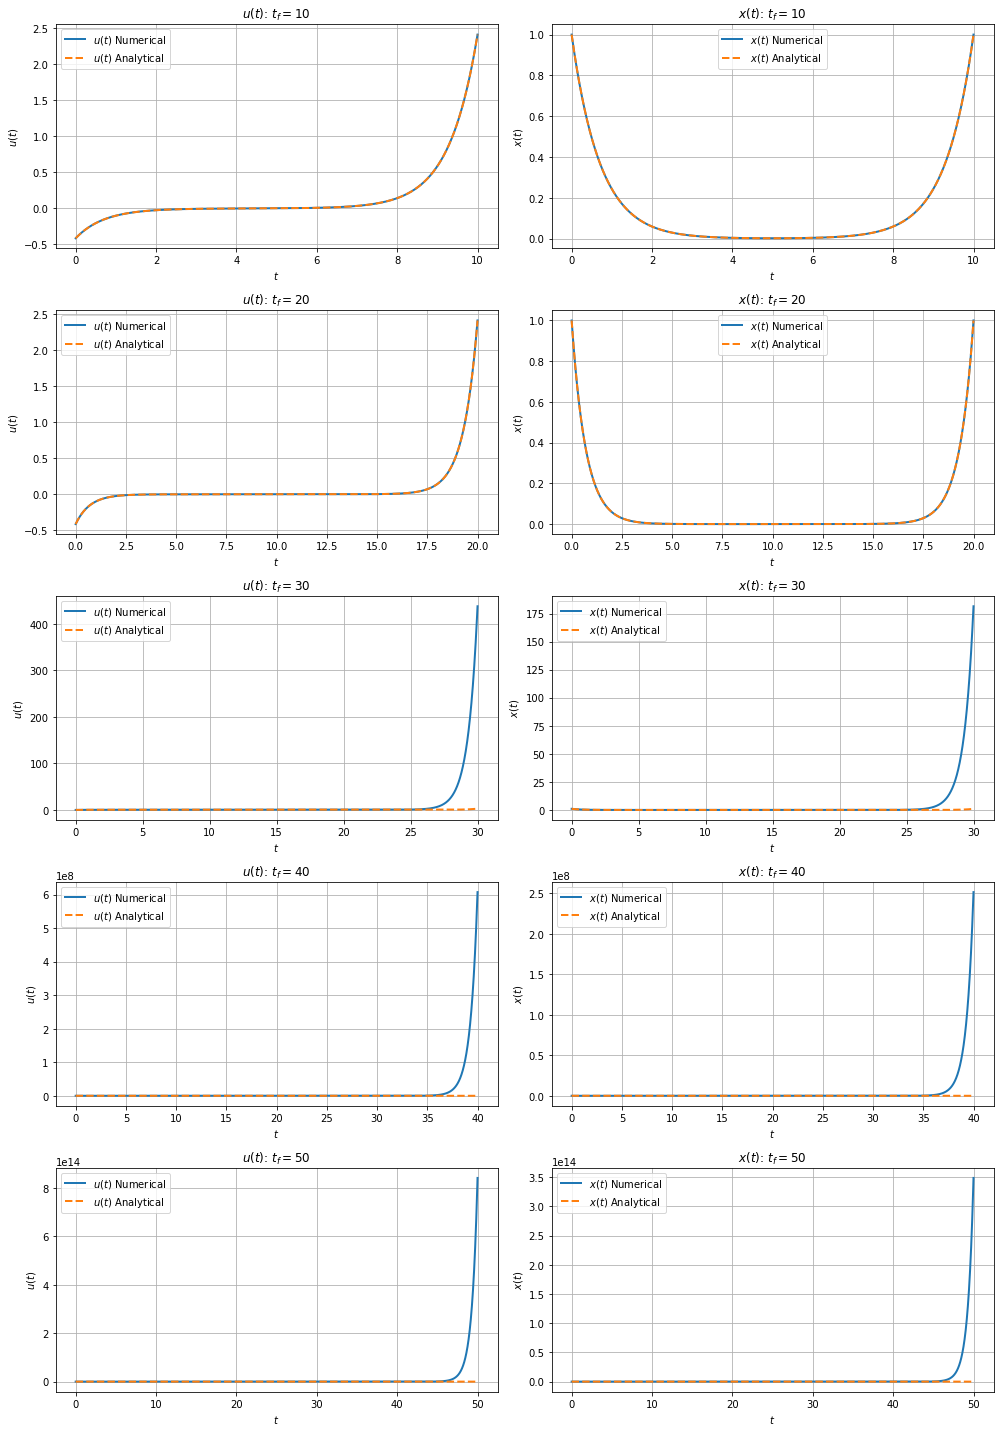

In [5]:
def analytical_u(t, tf):
    sqrt2 = np.sqrt(2)
    c1 = (1 - np.exp(-sqrt2 * tf)) / (np.exp(sqrt2 * tf) - np.exp(-sqrt2 * tf))
    c2 = 1 - c1
    return (1 + sqrt2) * c1 * np.exp(sqrt2 * t) - (sqrt2 - 1) * c2 * np.exp(-sqrt2 * t)

def analytical_x(t, tf):
    sqrt2 = np.sqrt(2)
    c1 = (1 - np.exp(-sqrt2 * tf)) / (np.exp(sqrt2 * tf) - np.exp(-sqrt2 * tf))
    c2 = 1 - c1
    return c1 * np.exp(sqrt2 * t) + c2 * np.exp(-sqrt2 * t)

def solve_and_compare(time_array):
    guess = 0
    fig, axes = plt.subplots(len(time_array),
                             2,
                             figsize=(14, 4*len(time_array)))
    
    for i, tf in enumerate(time_array):
        solution, info, ier, msg = fsolve(error,
                                          guess,
                                          args=(tf,),
                                           xtol=1e-8,
                                           full_output=True)
        lambda_0 = solution[0]
        x, lam, t = integrator(lambda_0, tf)
        
        u_numerical  = -lam
        u_analytical = analytical_u(t, tf)
        x_analytical = analytical_x(t, tf)

        # u(t) plots
        axes[i, 0].plot(t, u_numerical,  label='$u(t)$ Numerical',  
                        linewidth=2)
        axes[i, 0].plot(t, u_analytical, label='$u(t)$ Analytical',
                        linewidth=2, linestyle='--')
        axes[i, 0].set_title(f'$u(t)$: $t_f = {tf}$')
        axes[i, 0].set_xlabel('$t$')
        axes[i, 0].set_ylabel('$u(t)$')
        axes[i, 0].legend()
        axes[i, 0].grid(True)

        # x(t) plots
        axes[i, 1].plot(t, x,          label='$x(t)$ Numerical',
                        linewidth=2)
        axes[i, 1].plot(t, x_analytical, label='$x(t)$ Analytical',
                        linewidth=2, linestyle='--')
        axes[i, 1].set_title(f'$x(t)$: $t_f = {tf}$')
        axes[i, 1].set_xlabel('$t$')
        axes[i, 1].set_ylabel('$x(t)$')
        axes[i, 1].legend()
        axes[i, 1].grid(True)

        print(f"tf={tf}: max u(t) error = {np.max(np.abs(u_numerical - u_analytical)):.2e}, "
              f"max x(t) error = {np.max(np.abs(x - x_analytical)):.2e}")
        
        guess = lambda_0
    plt.tight_layout()
    plt.show()

solve_and_compare(time_array)

# Interpretation of differences:

# What happens to the ability to obtain a solution as tf increases?
Clearly there is a drastic difference between the numerical and analytical solution after $t_f=20$ - the ability to obtain a solution numerically breaks down around this time. Without using a guess from the prior iteration $t_f = 10$, converges actually breaks down as early as after $t_f = 10$. A solution can be found analytically for all times however. 
<br> <br>
Numerical solutions break down as a result of the relative sensitivity of $\delta x(t_f)$ to variations in initial guesses $\delta \lambda_0$. The sensitivity is derived in the general solution as being proportional to $e^{\sqrt{2}t_f}$ which grows exponentially, and for larger $t_f$'s requires fsolve to iterate $\delta \lambda_0$ 
by <b> extremely</b> small values to get an appropriate value of $t_f$, small enough that a double precision float cannot represent it, or smaller than the inputted tolerance. This causes fsolve to claim convergence since it cannot iterate it's initial guess by a small enough value to achieve better clearance. This applies for both the control and the x(t).
<br>
 
From a more compute oriented perspective, numerical solutions break down since $c_1$ is proportional to $e^{-\sqrt{2}t_f}$  which quickly becomes numerically indistingushible to zero from a floating point resolution perspective, causing issues for fsolve. Additionally, the integrator function also gets overwhelmed be the large values from $e^{\sqrt{2}t}$, and there becomes no meaningful way to vary the initial guess lambda(0) to make $x(t_f)$ approach zero due to limits in numerical resolution and a very large variation in $x_f$ from a small perterbation in the initial guess $\lambda_0$. The unstable eigenvalue $\sqrt(2)$ makes this varation ratio of $\delta \lambda_0$ to $\delta x(t_f)$ only grow larger and larger with $t_f$ making an iterative loop like fsolve be unable to converge properly on the solution. <br>

# what do you observe about the structure in the solution as tf increases?
As $t_f$ increases, there becomes a more drastic spike at the start and finish of the solution toward zero (at the start) or toward the boundary conditions (at the end) in order to reduce the stated cost function of $\frac{1}{2} \int_{0}^{t_f}\, [x^{2}(t) + u^{2}(t)] dt$. This behavior is created by the interaction of the stable and unstable eigenvectors as better described below: it's important to note the bahavior of the numerical solutions appears to attempt to mirror this, but fails to perterb the initial guess by small enough values to reach the appropriate end values within the perscribed tolerances. <br><br>


as described in the prior question, $c_1$ approaches zero and $c_2$ approaches 1 (sinze $c_2$ = 1-$c_1$), thus the $c_2$ term dominates the initial decay as $t$ increases - numerically this is exacerbated due to resolution limits on representing very small floating points. Integrator error grows proprotionally with $t_f$ as well. Contributions typically made by the unstable $c_1$ term are either dragged to zero from limitations on floating point resolutions, or are exacerbated massively as a small variation from the true $\lambda_0$ has a signifigant contribution at larger $t_f$ values, explaining the fsolve convergance without truly aligned end numerical values - it can't vary $\lambda_0$ by a small enough value anymore. It also explains the massive end peaks on each graph - they are a result of a slight variation in $\lambda$. This whole discussion is mirrored and applicable to the control u(t) for the same reasons.

# Problem 2:

Optimize:<br>
$$J = t_f$$

Subject to: <br>
$$ x' = vsin(\theta)$$
$$ y' = vcos(\theta)$$
$$ v' = gcos(\theta)$$

where g = 10<br>

Boundary conditions:


$$ x(0) = x_0 = 0 $$
$$ y(0) = y_0 = 0 $$
$$ v(0) = v_0 = 0$$
$$ x(t_f) = x_f = 2$$
$$ y(t_f) = y_f = 2$$
$$ v(t_f) = Free$$
$$ t_f = Free$$

Applying to general form:

$$\mathbf{\underline{x}}(t) = \begin{bmatrix} x(t) \\ y(t) \\ v(t) \end{bmatrix}$$

$$ u(t) = \theta(t)$$

costate: 
$$\underline{\lambda(t)} = (\lambda_x , \lambda_y, \lambda_v)$$

Hamiltonian:

$$H =  L + \underline{\lambda}^{T} \underline{f}(u,x)$$
where L = 0 thus,

$$H =  \lambda_xvsin(\theta) + \lambda_yvcos(\theta) + \lambda_vgcos(\theta)$$

# Derivation of general optimality conditions is included in appendix as this is already a bloated proof

Applying equations 1.1 - 1.3 from the appendix

$$\lambda'_x = - \frac{\partial H}{\partial x} = 0$$
$$\lambda'_y = - \frac{\partial H}{\partial y} = 0$$
$$\lambda'_v = - \frac{\partial H}{\partial v} = -\lambda_xsin(\theta) - \lambda_ycos(\theta)$$
$$\frac{\partial H}{\partial \theta} = 0 = \lambda_xvcos(\theta) - (\lambda_yv + \lambda_vg)sin(\theta) $$

This tells us $\lambda_x$ and $\lambda_y$ is a constant

Revisiting B.C.:

$$ x(0) = x_0 = 0 $$
$$ y(0) = y_0 = 0 $$
$$ v(0) = v_0 = 0$$
$$ x(t_f) = x_f = 2$$
$$ y(t_f) = y_f = 2$$
$$ v(t_f) = Free$$
$$ t_f = Free$$

This also implies:
$$\delta x_i = 0$$
$$\delta x_f = 0$$
$$\delta y_i = 0$$
$$\delta y_f = 0$$
$$\delta v_i = 0$$
$$\delta v_f \neq 0$$
$$\delta t_i = 0$$
$$\delta t_f \neq 0$$

Thus the following optimlatiy conditions applies (Non-zero variations dictate which apply) from (1.4):
$$ w_f = \frac{dm}{dt_f} - \mathbf{v}^T \frac{d\mathbf{b}}{dt_f} + H(t_f) $$
where
$$ \frac{d\mathbf{b}}{dt_f} = 0$$ 
so
$$ H(t_f) = -1$$

$$H\big|_{t_f} = [\lambda_x v\sin(\theta) + \lambda_y v\cos(\theta) + \lambda_v g\cos(\theta)]\big|_{t_f} = -1$$

$$-\lambda_v(t_f) + \frac{\partial M}{\partial v_f} + \mathbf{v}^T \frac{\partial \mathbf{b}}{\partial v_f} = 0$$

Since $\frac{\partial M}{\partial v_f} = 0$ and $\frac{\partial \mathbf{b}}{\partial v_f} = 0$:

$$-\lambda_v(t_f) = 0$$

So in summary we have the following 4 unkowns:

$$ (\lambda_x(0),\lambda_y(0),\lambda_v(0),t_f)$$ 

And the following 4 equations:

$$H\big|_{t_f} = [\lambda_x v\sin(\theta) + \lambda_y v\cos(\theta) + \lambda_v g\cos(\theta)]\big|_{t_f} + 1 = 0$$
$$-\lambda_v(t_f) = 0$$
$$x(t_f) - x_f = 0$$
$$y(t_f) - y_f = 0 $$

With the following constraints:

$$x' = vsin(\theta) \tag{2.1}$$
$$ y' = vcos(\theta) \tag{2.2}$$
$$ v' = gcos(\theta) \tag{2.3}$$

$$\lambda'_x = - \frac{\partial H}{\partial x} = 0 \tag{2.4}$$
$$\lambda'_y = - \frac{\partial H}{\partial y} = 0 \tag{2.5}$$
$$\lambda'_v = - \frac{\partial H}{\partial v} = -\lambda_xsin(\theta) - \lambda_ycos(\theta) \tag{2.6}$$
$$\frac{\partial H}{\partial \theta} = 0 = \lambda_xvcos(\theta) - (\lambda_yv + \lambda_vg)sin(\theta) \tag{2.7}$$


<div style="page-break-after: always;"></div>


# Code for solving problem 2 without root finding:

In [6]:
#imports
from scipy.optimize import root_scalar
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from scipy.optimize import newton

#Global variable decleration:
g = 10.0


def solve_theta_newton(lamx, lamy, lamv, v):

    A = lamx*v
    B = lamy*v + lamv*g

    def F(theta):
        return A*np.cos(theta) - B*np.sin(theta)

    def Fprime(theta):
        return -A*np.sin(theta) - B*np.cos(theta)

    theta0 = 0.0

    return newton(F, theta0, fprime=Fprime, tol=1e-10, maxiter=50)

In [7]:
def dynamics(t, z):
    x, y, v, lamx, lamy, lamv = z

    # Eq 2.7
    A = lamx * v
    B = lamy * v + lamv * g

    theta = np.arctan(A/B)
    #The below code works and should be used if root finding is perferred but it has a VERY large compute complexity
    #theta = solve_theta_newton(lamx, lamy, lamv, v)
    # End of eq. 2.7

    dxdt = v * np.sin(theta) #Eq. 2.1
    dydt = v * np.cos(theta) #Eq. 2.2
    dvdt = g * np.cos(theta) #Eq. 2.3

    dlamxdt = 0.0 #Constants Eq. 2.4
    dlamydt = 0.0 #Constants Eq. 2.5
    dlamvdt = -lamx*np.sin(theta) - lamy*np.cos(theta) #Eq. 2.6

    return [dxdt, dydt, dvdt, dlamxdt, dlamydt, dlamvdt] 

In [8]:
def integrator(lamx0, lamy0, lamv0, tf):
    z0 = [0, 0, 0, lamx0, lamy0, lamv0] #initial guess
    sol = solve_ivp(dynamics, [0, tf], z0, rtol=1e-8, atol=1e-8)
    #Given an initial guess will return the integrated
    #values from our dynamics
    return sol.y, sol.t 
def error(guess):

    lamx0, lamy0, lamv0, s = guess

    tf = np.exp(s)

    z, t = integrator(lamx0, lamy0, lamv0, tf)

    x_tf   = z[0, -1]
    y_tf   = z[1, -1]
    v_tf   = z[2, -1]
    lamx_tf = z[3, -1]
    lamy_tf = z[4, -1]
    lamv_tf = z[5, -1]

    # Compute theta at final time
    A = lamx_tf * v_tf
    B = lamy_tf * v_tf + lamv_tf * g
    theta_tf = np.arctan(A/B)
    #The below code works and should be used if root finding is perferred but it has a VERY large compute complexity
    #theta_tf = solve_theta_newton(lamx_tf, lamy_tf, lamv_tf, v_tf)

    # Hamiltonian 
    H_tf = (lamx_tf * v_tf * np.sin(theta_tf)
            + lamy_tf * v_tf * np.cos(theta_tf)
            + lamv_tf * g * np.cos(theta_tf))

    r1 = x_tf - 2
    r2 = y_tf - 2
    r3 = lamv_tf
    r4 = H_tf + 1

    return np.array([r1, r2, r3, r4])

In [9]:
initial_tf = 0.8165
guess = np.array([0.15, 0.056, -0.1, np.log(initial_tf)])
solution, info, ier, msg = fsolve(
    error,
    guess,
    xtol=1e-8,
    full_output=True
)

lamx0 = solution[0]
lamy0 = solution[1]
lamv0 = solution[2]
s     = solution[3]
tf = np.exp(s)  # convert back to physical final time
z, t = integrator(lamx0, lamy0, lamv0, tf)
print(f"lambda_x(0) = {lamx0:.10f}")
print(f"lambda_y(0) = {lamy0:.10f}")
print(f"lambda_v(0) = {lamv0:.10f}")
print(f"tf          = {tf:.10f}")
print(f"x(tf)       = {z[0,-1]:.10f}")
print(f"y(tf)       = {z[1,-1]:.10f}")
print(f"lambda_v(tf)= {z[5,-1]:.10f}")
print(f"Converged: {ier==1}, message: {msg}")

guess = solution


# Compute H along the full trajectory
lx, ly, lv, v_arr = z[3], z[4], z[5], z[2]
A = lx * v_arr
B = ly * v_arr + lv * g
theta_traj = np.arctan(A / B)
H_traj = (lx * v_arr * np.sin(theta_traj)
          + ly * v_arr * np.cos(theta_traj)
          + lv * g * np.cos(theta_traj))

print(f"H at tf        = {H_traj[-1]:.10f}")
print(f"Mean H over path        = {np.mean(H_traj):.10f}")


lambda_x(0) = -0.1477097414
lambda_y(0) = -0.0564077326
lambda_v(0) = -0.1000000000
tf          = 0.8164698967
x(tf)       = 2.0000000000
y(tf)       = 2.0000000000
lambda_v(tf)= -0.0000000000
Converged: True, message: The solution converged.
H at tf        = -1.0000000000
Mean H over path        = -0.9999999999


# Start code with root finding (No use of tan in solving for theta)

In [10]:
#imports
from scipy.optimize import root_scalar
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from scipy.optimize import newton

#Global variable decleration:
g = 10.0

_theta_cache = [0.0]

In [11]:
def solve_theta_newton(lamx, lamy, lamv, v):
    A = lamx*v
    B = lamy*v + lamv*g
    def F(theta):
        return A*np.cos(theta) - B*np.sin(theta)
    def Fprime(theta):
        return -A*np.sin(theta) - B*np.cos(theta)
    #Unoptimized version of code
    #theta0 = 0.0
    #return newton(F, theta0, fprime=Fprime, tol=1e-10, maxiter=50)

    theta0 = _theta_cache[0]
    try:
        result = newton(F,
                        theta0,
                        fprime=Fprime,
                        tol=1e-10,
                        maxiter=10)
        _theta_cache[0] = result
        return result
    except RuntimeError:
        print("ERROR")
        return -1

def dynamics(t, z):
    x, y, v, lamx, lamy, lamv = z

    # Eq 2.7
    A = lamx * v
    B = lamy * v + lamv * g

    #Old non-root finding method (works)
    #theta = np.arctan(A/B)

    theta = solve_theta_newton(lamx, lamy, lamv, v)

    # End of eq. 2.7

    dxdt  = v * np.sin(theta)                          #Eq. 2.1
    dydt  = v * np.cos(theta)                          #Eq. 2.2
    dvdt  = g * np.cos(theta)                          #Eq. 2.3
    dlamxdt = 0.0                                      #Constants Eq. 2.4
    dlamydt = 0.0                                      #Constants Eq. 2.5
    dlamvdt = -lamx*np.sin(theta) - lamy*np.cos(theta) #Eq. 2.6

    return [dxdt, dydt, dvdt, dlamxdt, dlamydt, dlamvdt]


In [12]:
def integrator(lamx0, lamy0, lamv0, tf):

    _theta_cache[0] = 0.0

    z0 = [0, 0, 0, lamx0, lamy0, lamv0] #initial guess
    sol = solve_ivp(dynamics, [0, tf], z0, rtol=1e-8, atol=1e-8)
    return sol.y, sol.t

def error(guess):
    lamx0, lamy0, lamv0, s = guess
    tf = np.exp(s)
    z, t = integrator(lamx0, lamy0, lamv0, tf)

    x_tf    = z[0, -1]
    y_tf    = z[1, -1]
    v_tf    = z[2, -1]
    lamx_tf = z[3, -1]
    lamy_tf = z[4, -1]
    lamv_tf = z[5, -1]

    # Compute theta at final time
    A = lamx_tf * v_tf
    B = lamy_tf * v_tf + lamv_tf * g

    # theta_tf = np.arctan(A/B)

    theta_tf = solve_theta_newton(lamx_tf, lamy_tf, lamv_tf, v_tf)

    # Hamiltonian
    H_tf = (lamx_tf * v_tf * np.sin(theta_tf)
            + lamy_tf * v_tf * np.cos(theta_tf)
            + lamv_tf * g * np.cos(theta_tf))

    r1 = x_tf - 2
    r2 = y_tf - 2
    r3 = lamv_tf
    r4 = H_tf + 1

    return np.array([r1, r2, r3, r4])

In [13]:
initial_tf = 0.8165
guess = np.array([0.15, 0.056, -0.1, np.log(initial_tf)])
solution, info, ier, msg = fsolve(
    error,
    guess,
    xtol=1e-8,
    full_output=True
)

lamx0 = solution[0]
lamy0 = solution[1]
lamv0 = solution[2]
s     = solution[3]
tf = np.exp(s)  # convert back to physical final time
z, t = integrator(lamx0, lamy0, lamv0, tf)

print(f"lambda_x(0) = {lamx0:.10f}")
print(f"lambda_y(0) = {lamy0:.10f}")
print(f"lambda_v(0) = {lamv0:.10f}")
print(f"tf          = {tf:.10f}")
print(f"x(tf)       = {z[0,-1]:.10f}")
print(f"y(tf)       = {z[1,-1]:.10f}")
print(f"lambda_v(tf)= {z[5,-1]:.10f}")
print(f"Converged: {ier==1}, message: {msg}")
guess = solution

# Compute H along the full trajectory
lx, ly, lv, v_arr = z[3], z[4], z[5], z[2]
A = lx * v_arr
B = ly * v_arr + lv * g

# theta_traj = np.arctan(A / B)

theta_traj = np.arctan(A / B)

H_traj = (lx * v_arr * np.sin(theta_traj)
          + ly * v_arr * np.cos(theta_traj)
          + lv * g * np.cos(theta_traj))

print(f"H at tf             = {H_traj[-1]:.10f}")
print(f"Mean H over path    = {np.mean(H_traj):.10f}")

lambda_x(0) = -0.1477097414
lambda_y(0) = -0.0564077326
lambda_v(0) = -0.1000000000
tf          = 0.8164698967
x(tf)       = 2.0000000000
y(tf)       = 2.0000000000
lambda_v(tf)= -0.0000000000
Converged: True, message: The solution converged.
H at tf             = -1.0000000000
Mean H over path    = -0.9999999999


<div style="page-break-after: always;"></div>


# Found trajectories x(t), y(t), v(t), and $\theta(t)$

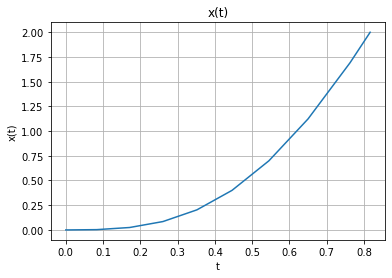

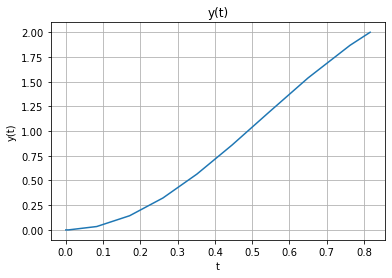

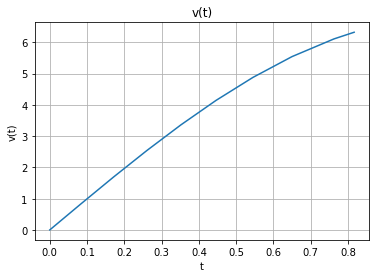

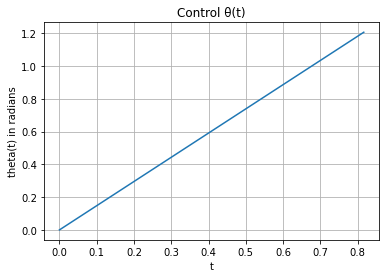

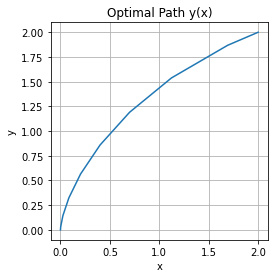

In [14]:
import matplotlib.pyplot as plt

x = z[0]
y = z[1]
v = z[2]
lx = z[3]
ly = z[4]
lv = z[5]

A = lx * v
B = ly * v + lv * g
theta = np.arctan(A/B)

# 1) x(t), y(t)
plt.figure()
plt.plot(t, x)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("x(t)")
plt.grid()

plt.figure()
plt.plot(t, y)
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("y(t)")
plt.grid()

# 2) v(t)
plt.figure()
plt.plot(t, v)
plt.xlabel("t")
plt.ylabel("v(t)")
plt.title("v(t)")
plt.grid()

# 3) theta(t)
plt.figure()
plt.plot(t, theta)
plt.xlabel("t")
plt.ylabel("theta(t) in radians")
plt.title("Control θ(t)")
plt.grid()

# 4) spatial curve y(x)
plt.figure()
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Optimal Path y(x)")
plt.gca().set_aspect('equal', adjustable='box')
plt.grid()

plt.show()

<div style="page-break-after: always;"></div>


# Appendix: Derivation of General Optimality Conditions


Minimize the **Bolza cost**:

$$J = M\!\left(\mathbf{x}(t_f),\, t_f\right) + \int_{t_0}^{t_f} L\!\left(\mathbf{x},\, u,\, t\right) dt$$

subject to:

$$\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x}, u, t), \qquad \mathbf{b}\!\left(\mathbf{x}(t_0), t_0,\, \mathbf{x}(t_f), t_f\right) = \mathbf{0}$$


Append dynamics via costate $\boldsymbol{\lambda}(t)$ and boundary constraints via multipliers $\boldsymbol{\nu}$:

$$J_a = M(\mathbf{x}_f, t_f) - \boldsymbol{\nu}^T \mathbf{b} + \int_{t_0}^{t_f}\!\left[L + \boldsymbol{\lambda}^T\!\left(\mathbf{f} - \dot{\mathbf{x}}\right)\right] dt$$

Define the Hamiltonian:

$$\boxed{H(\mathbf{x}, u, \boldsymbol{\lambda}, t) = L(\mathbf{x}, u, t) + \boldsymbol{\lambda}^T \mathbf{f}(\mathbf{x}, u, t)}$$

So that:

$$J_a = M(\mathbf{x}_f, t_f) - \boldsymbol{\nu}^T \mathbf{b} + \int_{t_0}^{t_f}\!\left[H - \boldsymbol{\lambda}^T \dot{\mathbf{x}}\right] dt$$


Take $\delta J_a = 0$. Integrate $\boldsymbol{\lambda}^T \delta\dot{\mathbf{x}}$ by parts:

$$\int_{t_0}^{t_f} \boldsymbol{\lambda}^T \delta\dot{\mathbf{x}}\, dt = \Big[\boldsymbol{\lambda}^T \delta\mathbf{x}\Big]_{t_0}^{t_f} - \int_{t_0}^{t_f} \dot{\boldsymbol{\lambda}}^T \delta\mathbf{x}\, dt$$

Collecting terms in $\delta\mathbf{x}$ and $\delta u$:

$$\delta J_a = (\text{endpoint terms}) + \int_{t_0}^{t_f}\!\left[\left(\frac{\partial H}{\partial \mathbf{x}} + \dot{\boldsymbol{\lambda}}\right)^T\!\delta\mathbf{x} + \frac{\partial H}{\partial u}^T\!\delta u\right] dt = 0 \tag{1.1}$$


**Costate equations** (coefficient of $\delta\mathbf{x}$ in integrand):
$$\dot{\boldsymbol{\lambda}} = -\frac{\partial H}{\partial \mathbf{x}} \tag{1.2}$$

**Stationarity** (coefficient of $\delta u$ in integrand):
$$\frac{\partial H}{\partial u} = \mathbf{0} \tag{1.3}$$


The endpoint terms arise from three sources: the variation of the Mayer term $M$, the variation of the boundary constraint term $\boldsymbol{\nu}^T\mathbf{b}$, and the boundary evaluation of the integration by parts. Expanding each:

**Variation of $M(\mathbf{x}(t_0), t_0, \mathbf{x}(t_f), t_f)$:**

$$\delta M = \frac{\partial M}{\partial \mathbf{x}(t_0)}\delta\mathbf{x}_0 + \frac{\partial M}{\partial t_0}\delta t_0 + \frac{\partial M}{\partial \mathbf{x}(t_f)}\delta\mathbf{x}_f + \frac{\partial M}{\partial t_f}\delta t_f$$

**Variation of $\boldsymbol{\nu}^T\mathbf{b}(\mathbf{x}(t_0), t_0, \mathbf{x}(t_f), t_f)$:**

$$\delta(\boldsymbol{\nu}^T \mathbf{b}) = \boldsymbol{\nu}^T\frac{\partial \mathbf{b}}{\partial \mathbf{x}(t_0)}\delta\mathbf{x}_0 + \boldsymbol{\nu}^T\frac{\partial \mathbf{b}}{\partial t_0}\delta t_0 + \boldsymbol{\nu}^T\frac{\partial \mathbf{b}}{\partial \mathbf{x}(t_f)}\delta\mathbf{x}_f + \boldsymbol{\nu}^T\frac{\partial \mathbf{b}}{\partial t_f}\delta t_f$$

**Boundary evaluation of integration by parts:**

$$\Big[\boldsymbol{\lambda}^T \delta\mathbf{x}\Big]_{t_0}^{t_f} = \boldsymbol{\lambda}^T(t_f)\delta\mathbf{x}_f - \boldsymbol{\lambda}^T(t_0)\delta\mathbf{x}_0$$

Note that when the limits of integration are varied by $\delta t_0$ and $\delta t_f$, the Hamiltonian evaluated at the endpoints contributes:

$$\Big[H\Big]_{t_0}^{t_f}\cdot(\text{limit variations}) = H(t_f)\,\delta t_f - H(t_0)\,\delta t_0$$

Combining all endpoint contributions and grouping by variation:

$$\delta J_a\big|_{\text{endpoint}} = \left[\frac{\partial M}{\partial \mathbf{x}_0} - \boldsymbol{\nu}^T\frac{\partial \mathbf{b}}{\partial \mathbf{x}_0} + \boldsymbol{\lambda}^T(t_0)\right]\delta\mathbf{x}_0 + \left[\frac{\partial M}{\partial \mathbf{x}_f} - \boldsymbol{\nu}^T\frac{\partial \mathbf{b}}{\partial \mathbf{x}_f} - \boldsymbol{\lambda}^T(t_f)\right]\delta\mathbf{x}_f + \left[\frac{\partial M}{\partial t_0} - \boldsymbol{\nu}^T\frac{\partial \mathbf{b}}{\partial t_0} - H(t_0)\right]\delta t_0 + \left[\frac{\partial M}{\partial t_f} - \boldsymbol{\nu}^T\frac{\partial \mathbf{b}}{\partial t_f} + H(t_f)\right]\delta t_f = 0$$

Define the four **transversality conditions**:

$$T_0 = \left[\boldsymbol{\lambda}^T(t_0) + \frac{\partial M}{\partial \mathbf{x}(t_0)} - \boldsymbol{\nu}^T \frac{\partial \mathbf{b}}{\partial \mathbf{x}(t_0)}\right]^T$$

$$T_f = \left[-\boldsymbol{\lambda}^T(t_f) + \frac{\partial M}{\partial \mathbf{x}(t_f)} - \boldsymbol{\nu}^T \frac{\partial \mathbf{b}}{\partial \mathbf{x}(t_f)}\right]^T$$

$$W_0 = \frac{\partial M}{\partial t_0} - \boldsymbol{\nu}^T \frac{\partial \mathbf{b}}{\partial t_0} - H(t_0)$$

$$W_f = \frac{\partial M}{\partial t_f} - \boldsymbol{\nu}^T \frac{\partial \mathbf{b}}{\partial t_f} + H(t_f)$$

So that the endpoint condition is written compactly as:

$$T_0^T\, \delta\mathbf{x}_0 + T_f^T\, \delta\mathbf{x}_f + W_0\, \delta t_0 + W_f\, \delta t_f = 0 \tag{1.4}$$

For each term, either the variation is zero (fixed boundary) or the corresponding condition must be zero (free boundary):

- $\delta \mathbf{x}_0 \neq 0 \;\Rightarrow\; T_0 = \mathbf{0}$
- $\delta \mathbf{x}_f \neq 0 \;\Rightarrow\; T_f = \mathbf{0}$
- $\delta t_0 \neq 0 \;\Rightarrow\; W_0 = 0$
- $\delta t_f \neq 0 \;\Rightarrow\; W_f = 0$